In [2]:

import numpy as np
import requests
import matplotlib.pyplot as plt

from gpt_model1 import TokenDataset, GPTModel1
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken

In [3]:
# tokenize the text
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tokenizer = tiktoken.get_encoding('cl100k_base')

# text needs to be pytorch tensors
tokens = tokenizer.encode(text)
print(f'Variable "tokens" is type {type(tokens)}')

# convert to pytorch
tmTokens = torch.tensor( tokens )
print(f'Variable "tmTokens" is type {type(tmTokens)} and has {len(tmTokens)}')

Variable "tokens" is type <class 'list'>
Variable "tmTokens" is type <class 'torch.Tensor'> and has 43053


In [4]:
# Hyper parameters
seq_len = 8 # aka context length
stride = 2
n_vocab = tokenizer.n_vocab
print("Vocab size = ", n_vocab)

# model hyperparameters
embed_dim = 2**6 # 64

batch_size = 5

Vocab size =  100277


In [5]:
token_dataset = TokenDataset(tokenizer, text, seq_len, stride)
# print(len(token_dataset))
token_dataset[4]

dataloader = DataLoader(
                token_dataset,
                batch_size = batch_size,
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print("X shape ", X.shape)
print("y shape ", y.shape)
print(tokenizer.decode(X.detach().numpy()[0]))
print(tokenizer.decode(y.detach().numpy()[0]))

X shape  torch.Size([5, 8])
y shape  torch.Size([5, 8])
 vanished as I rubbed my eyes. The
 as I rubbed my eyes. The Time


Embedding shape  torch.Size([100277, 64])
Input shape  torch.Size([8])
Afetr EMB shape  torch.Size([8, 64])
Afetr gelu shape  torch.Size([8, 64])
Fial gelu shape  torch.Size([8, 100277])
torch.Size([5, 8])
torch.Size([5, 8])
torch.Size([8, 100277])


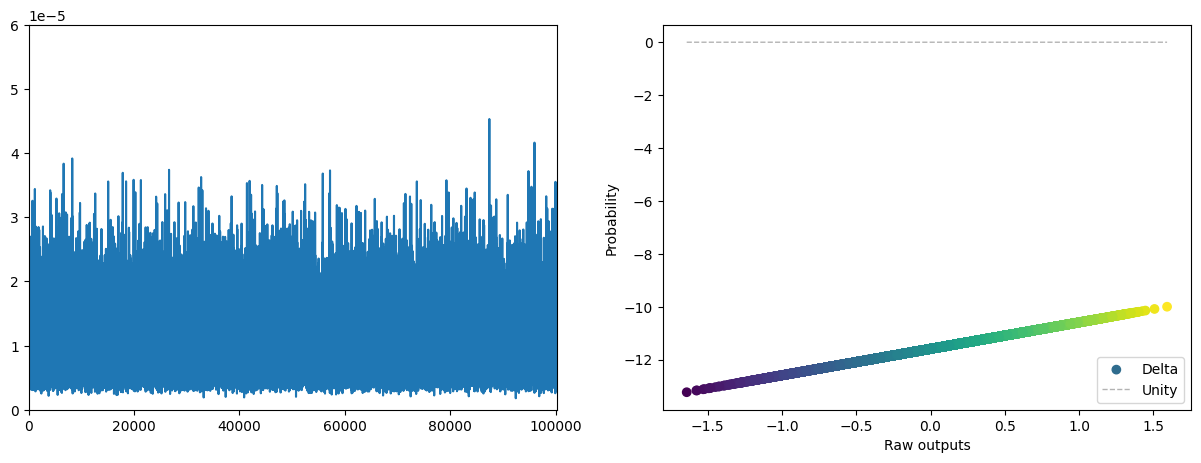

In [ ]:
# new instance of the model


model = GPTModel1(n_vocab, embed_dim)

# get some data
# X,y = token_dataset[12345]

# process the tokens (forward pass)
out = model(X[1,:])

print(X.shape)
print(y.shape)
print(out.shape) # [tokens, vocab_size]
last = out[-1, :]
soft_max_last = torch.exp(last) / torch.exp(last).sum()

_, axs = plt.subplots(1,2, figsize=(15, 5))
x = axs[0].plot(soft_max_last.detach().numpy())
axs[0].set_xlim(0, n_vocab)
axs[0].set_ylim(0, 0.00006)
axs[1].scatter(last.detach().numpy(), soft_max_last.detach().numpy(), c=last.detach().numpy(), label="Delta")
axs[1].plot([torch.min(last).detach(),torch.max(last).detach()],[torch.min(soft_max_last).detach(),torch.max(soft_max_last).detach()],
            '--',color=[.7,.7,.7],linewidth=1,label='Unity',zorder=-10)
axs[1].set(xlabel='Raw outputs',ylabel='Probability')
axs[1].legend()


In [6]:
out = model(X)
print("Input shape:", X.shape)
print("Output shape:", out.shape)

Input shape  torch.Size([5, 8])
Afetr EMB shape  torch.Size([5, 8, 64])
Afetr gelu shape  torch.Size([5, 8, 64])
Fial gelu shape  torch.Size([5, 8, 100277])
Input shape: torch.Size([5, 8])
Output shape: torch.Size([5, 8, 100277])


In [16]:
x = torch.randn((2,3,4))
print(x)
print("\n")
print(x[:, -1, :])
print(x[:, -1, :].shape)

tensor([[[ 1.6883e+00,  2.3191e-01,  4.3344e-01,  4.3391e-01],
         [ 1.3158e+00, -6.2634e-01,  1.7788e-01, -5.0374e-01],
         [ 2.6970e-01, -1.2162e+00, -2.3844e-01, -1.0303e-01]],

        [[-1.4251e+00, -2.3972e-01, -1.9811e-01,  8.2933e-01],
         [ 7.9433e-02,  5.2931e-01, -1.9620e+00,  1.1234e+00],
         [-4.5140e-01,  1.5872e-03,  1.7274e+00, -9.8185e-02]]])


tensor([[ 2.6970e-01, -1.2162e+00, -2.3844e-01, -1.0303e-01],
        [-4.5140e-01,  1.5872e-03,  1.7274e+00, -9.8185e-02]])
torch.Size([2, 4])
